In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / "datasets"
FIGURE_DIR = PROJECT_ROOT / "figures" / "PB2_KNMI"

combined_path = OUTPUT_DIR / "knmi_combined_2015plus_preprocessed.csv"
final_knmi = pd.read_csv(combined_path)

## 11. Correlation matrix for PB2-02

For wind direction, the interpolated degrees are not ideal for correlation because direction is circular. Therefore, the matrix uses `wind_dir_sin` and `wind_dir_cos` to represent wind direction numerically.

In [11]:
corr_cols = [
    "wind_speed_ms",
    "wind_gust_ms",
    "temperature_c",
    "dew_point_c",
    "pressure_hpa",
    "humidity_pct",
    "cloud_cover_octants",
    "global_radiation_j_cm2",
    "precipitation_mm",
    "wind_dir_sin",
    "wind_dir_cos"
]

corr_cols = [c for c in corr_cols if c in final_knmi.columns]

corr = final_knmi[corr_cols].corr()
display(corr)

corr_path = OUTPUT_DIR / "knmi_weather_wind_correlation_matrix.csv"
corr.to_csv(corr_path)
print("Saved correlation matrix to:", corr_path)

,wind_speed_ms,wind_gust_ms,temperature_c,dew_point_c,pressure_hpa,humidity_pct,cloud_cover_octants,global_radiation_j_cm2,precipitation_mm,wind_dir_sin,wind_dir_cos
wind_speed_ms,1.000000,0.955577,-0.063407,-0.107127,-0.333204,-0.105596,0.139040,0.018428,0.068746,-0.218710,-0.076766
wind_gust_ms,0.955577,1.000000,-0.064699,-0.114274,-0.362415,-0.118607,0.157666,0.007553,0.123818,-0.266448,-0.065221
temperature_c,-0.063407,-0.064699,1.000000,0.897059,-0.001831,-0.374945,-0.088130,0.461053,-0.014596,-0.085260,0.053491
dew_point_c,-0.107127,-0.114274,0.897059,1.000000,-0.067020,0.066529,0.034772,0.209558,0.050240,-0.133490,-0.048740
pressure_hpa,-0.333204,-0.362415,-0.001831,-0.067020,1.000000,-0.136956,-0.228267,0.114430,-0.158402,0.116303,0.244098
humidity_pct,-0.105596,-0.118607,-0.374945,0.066529,-0.136956,1.000000,0.282375,-0.587554,0.149953,-0.068447,-0.246850
cloud_cover_octants,0.139040,0.157666,-0.088130,0.034772,-0.228267,0.282375,1.000000,-0.228782,0.090186,-0.146279,-0.148811
global_radiation_j_cm2,0.018428,0.007553,0.461053,0.209558,0.114430,-0.587554,-0.228782,1.000000,-0.088169,-0.017414,0.167767
precipitation_mm,0.068746,0.123818,-0.014596,0.050240,-0.158402,0.149953,0.090186,-0.088169,1.000000,-0.043486,-0.030349
wind_dir_sin,-0.218710,-0.266448,-0.085260,-0.133490,0.116303,-0.068447,-0.146279,-0.017414,-0.043486,1.000000,0.104393


Saved correlation matrix to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\datasets\knmi_weather_wind_correlation_matrix.csv


## 12. Graph 1: Correlation heatmap

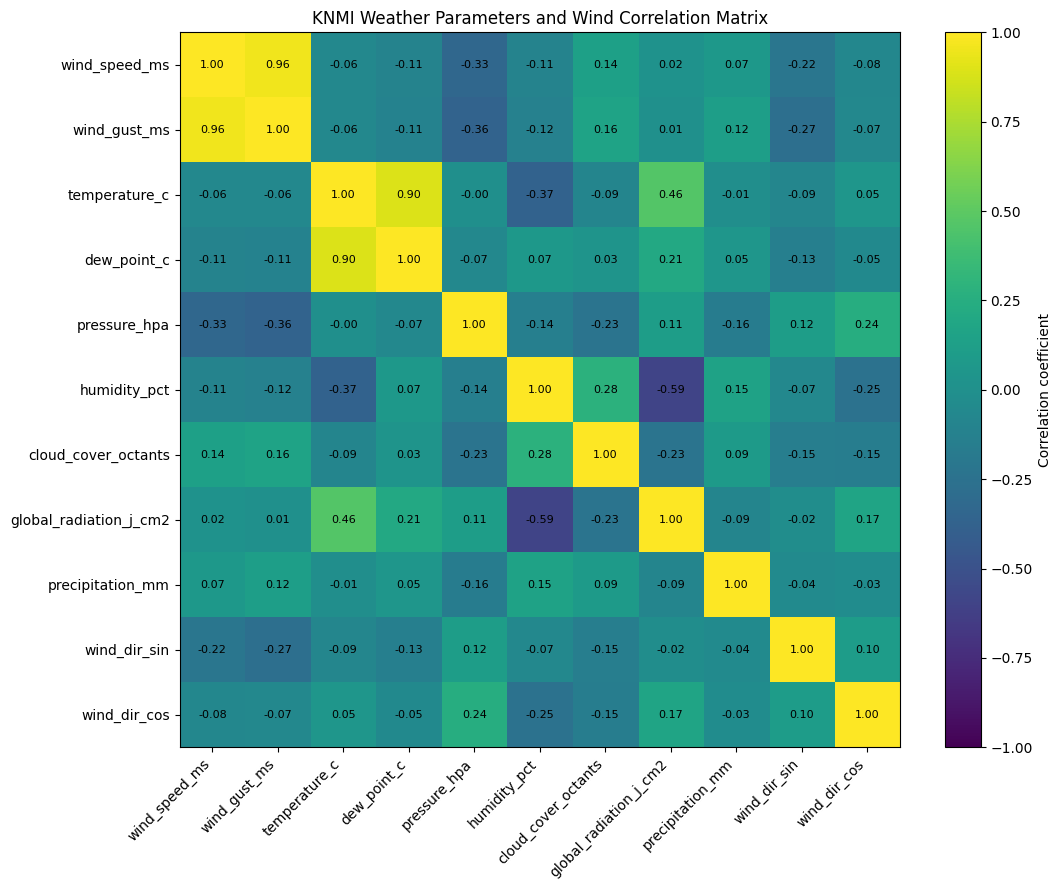

In [13]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation coefficient")
ax.set_title("KNMI Weather Parameters and Wind Correlation Matrix")
plt.tight_layout()

heatmap_path = FIGURE_DIR / "knmi_correlation_heatmap.png"
plt.show()

## 13. Graph 2: Wind speed vs temperature

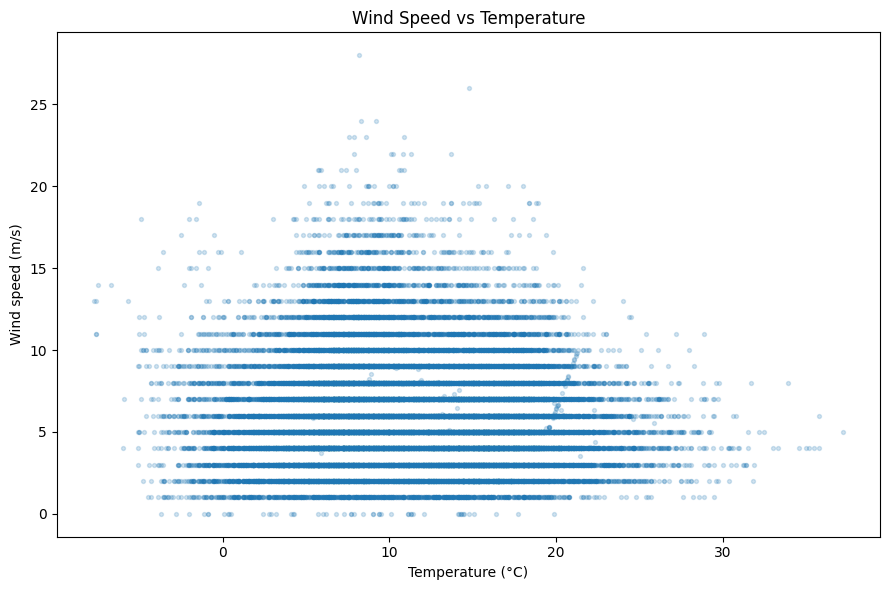

In [15]:
plot_data = final_knmi.dropna(subset=["wind_speed_ms", "temperature_c"])
plot_sample = plot_data.sample(min(30000, len(plot_data)), random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(plot_sample["temperature_c"], plot_sample["wind_speed_ms"], alpha=0.2, s=8)
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind speed (m/s)")
plt.title("Wind Speed vs Temperature")
plt.tight_layout()

temp_path = FIGURE_DIR / "wind_speed_vs_temperature.png"
plt.show()

## 14. Graph 3: Wind speed vs air pressure

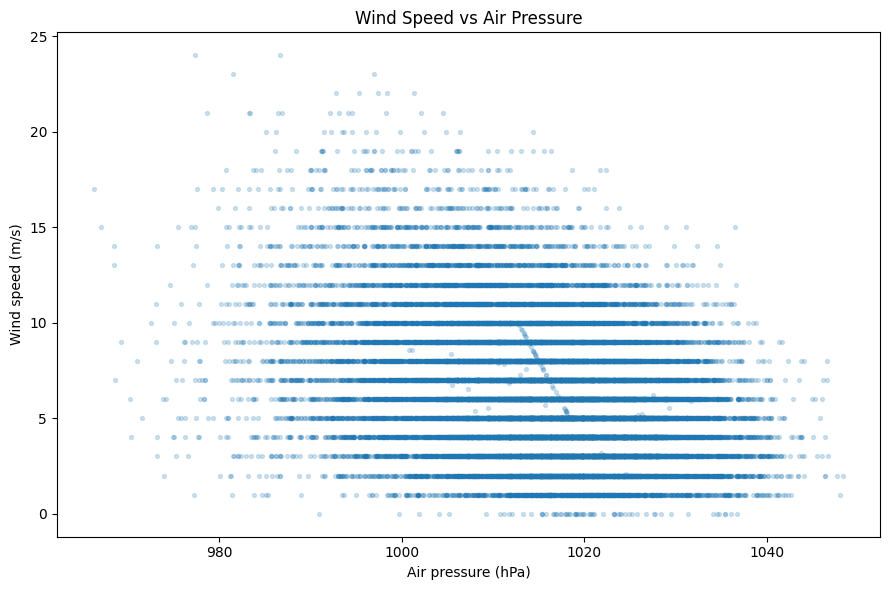

In [17]:
plot_data = final_knmi.dropna(subset=["wind_speed_ms", "pressure_hpa"])
plot_sample = plot_data.sample(min(30000, len(plot_data)), random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(plot_sample["pressure_hpa"], plot_sample["wind_speed_ms"], alpha=0.2, s=8)
plt.xlabel("Air pressure (hPa)")
plt.ylabel("Wind speed (m/s)")
plt.title("Wind Speed vs Air Pressure")
plt.tight_layout()

pressure_path = FIGURE_DIR / "wind_speed_vs_pressure.png"
plt.savefig(pressure_path, dpi=200)
plt.show()

## 15. Graph 4: Wind speed by cloud cover

Cloud cover is measured in octants. A value of 0 means clear sky, while 8 means fully covered. A value of 9 means the sky is invisible.

C:\Users\lackn\AppData\Local\Temp\ipykernel_1004\1854693482.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


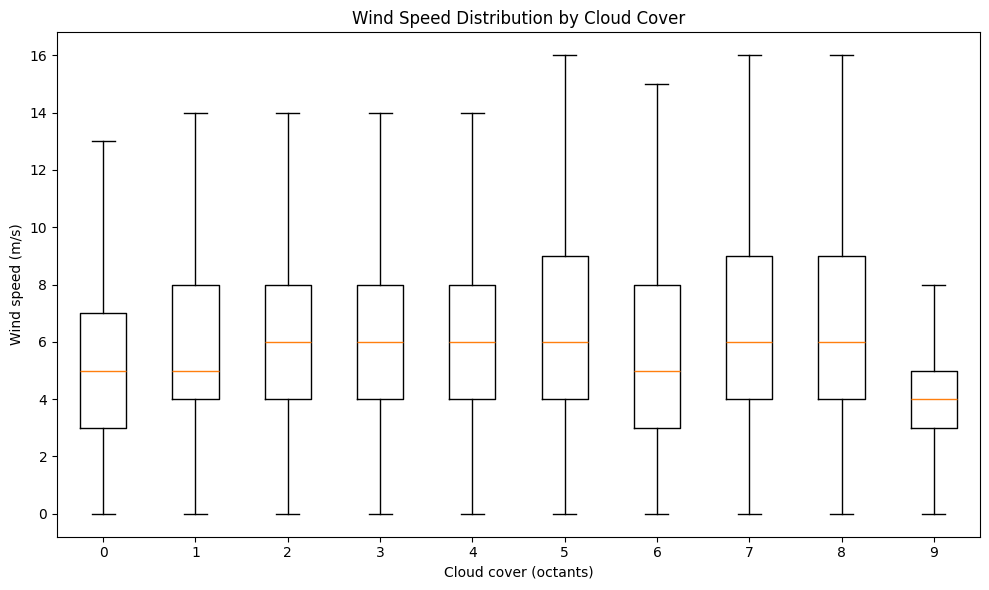

In [19]:
if "cloud_cover_octants" in final_knmi.columns:
    box_data = final_knmi.dropna(subset=["wind_speed_ms", "cloud_cover_octants"]).copy()
    box_data["cloud_cover_octants"] = box_data["cloud_cover_octants"].round().astype(int)

    groups = []
    labels = []
    for cloud_value in sorted(box_data["cloud_cover_octants"].unique()):
        values = box_data.loc[box_data["cloud_cover_octants"] == cloud_value, "wind_speed_ms"].dropna()
        if len(values) > 0:
            groups.append(values.sample(min(5000, len(values)), random_state=42))
            labels.append(str(cloud_value))

    plt.figure(figsize=(10, 6))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.xlabel("Cloud cover (octants)")
    plt.ylabel("Wind speed (m/s)")
    plt.title("Wind Speed Distribution by Cloud Cover")
    plt.tight_layout()

    cloud_path = FIGURE_DIR / "wind_speed_by_cloud_cover_boxplot.png"
    plt.show()
else:
    print("cloud_cover_octants column is not available.")

## 16. Graph 5: Monthly average wind speed by station

This graph is useful for checking whether the merged station datasets look sensible after combining the split year files.

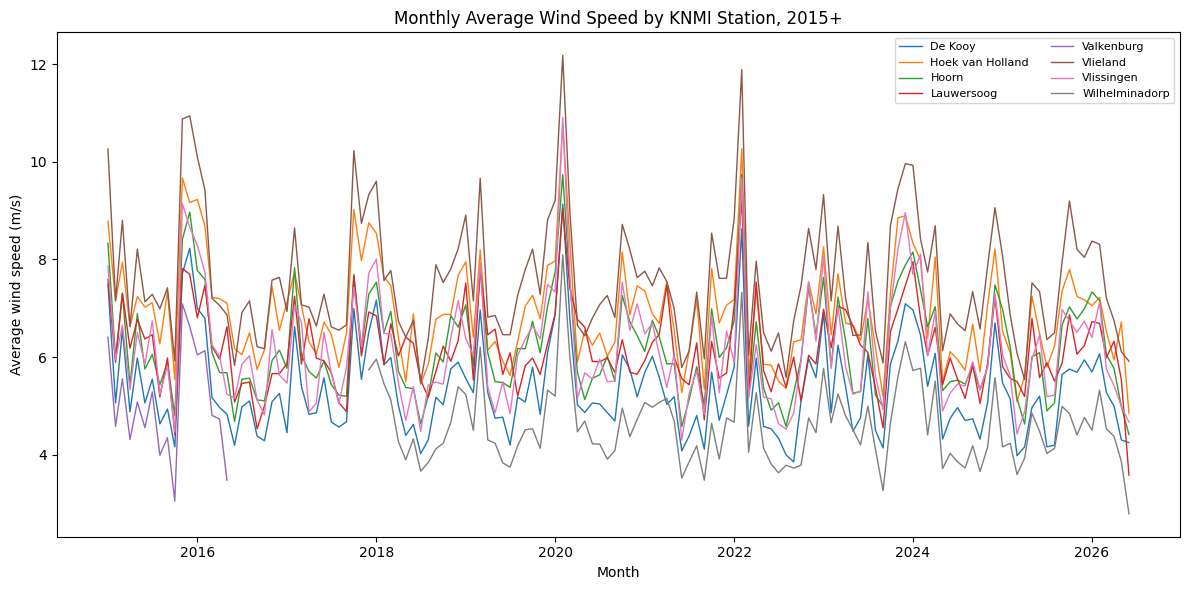

In [22]:
monthly = final_knmi.copy()
monthly["timestamp"] = pd.to_datetime(monthly["timestamp"])
monthly["month"] = monthly["timestamp"].dt.to_period("M").dt.to_timestamp()
monthly_avg = monthly.groupby(["month", "Station"], as_index=False)["wind_speed_ms"].mean()

plt.figure(figsize=(12, 6))
for station, group in monthly_avg.groupby("Station"):
    plt.plot(group["month"], group["wind_speed_ms"], label=station, linewidth=1)

plt.xlabel("Month")
plt.ylabel("Average wind speed (m/s)")
plt.title("Monthly Average Wind Speed by KNMI Station, 2015+")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()

monthly_path = FIGURE_DIR / "monthly_average_wind_speed_by_station.png"
plt.show()

## 17. Strongest correlations with wind speed

This table helps with the written explanation for PB2-02.

In [38]:
if "wind_speed_ms" in corr.columns:
    strongest = (
        corr["wind_speed_ms"]
        .drop("wind_speed_ms")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .reset_index()
    )
    strongest.columns = ["variable", "correlation_with_wind_speed"]
    display(strongest)

    strongest.to_csv(OUTPUT_DIR / "knmi_strongest_correlations_with_wind_speed.csv", index=False)
    print("Saved strongest correlation table")
else:
    print("wind_speed_ms not available in correlation matrix.")

,variable,correlation_with_wind_speed
0,wind_gust_ms,0.955577
1,pressure_hpa,-0.333204
2,wind_dir_sin,-0.218710
3,cloud_cover_octants,0.139040
4,dew_point_c,-0.107127
5,humidity_pct,-0.105596
6,wind_dir_cos,-0.076766
7,precipitation_mm,0.068746
8,temperature_c,-0.063407
9,global_radiation_j_cm2,0.018428


Saved strongest correlation table


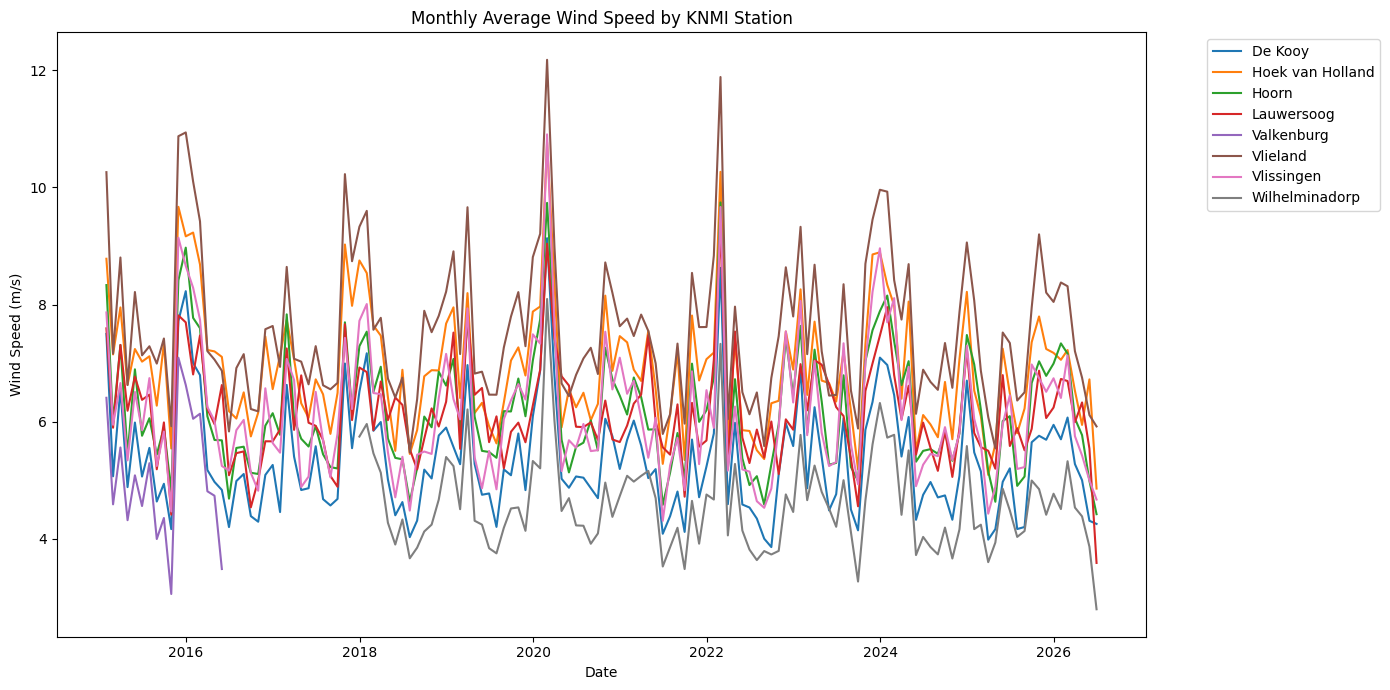

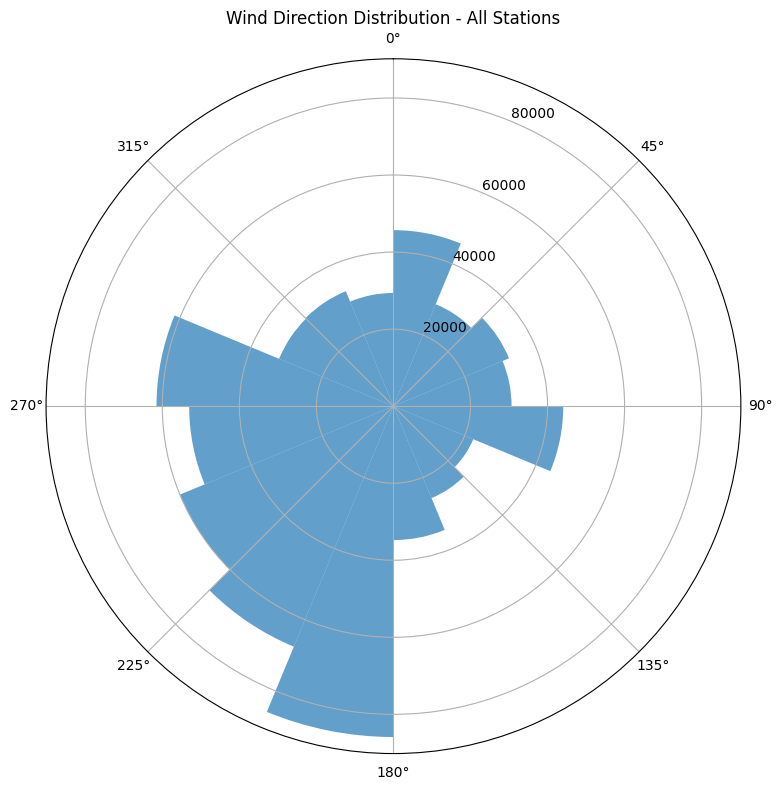

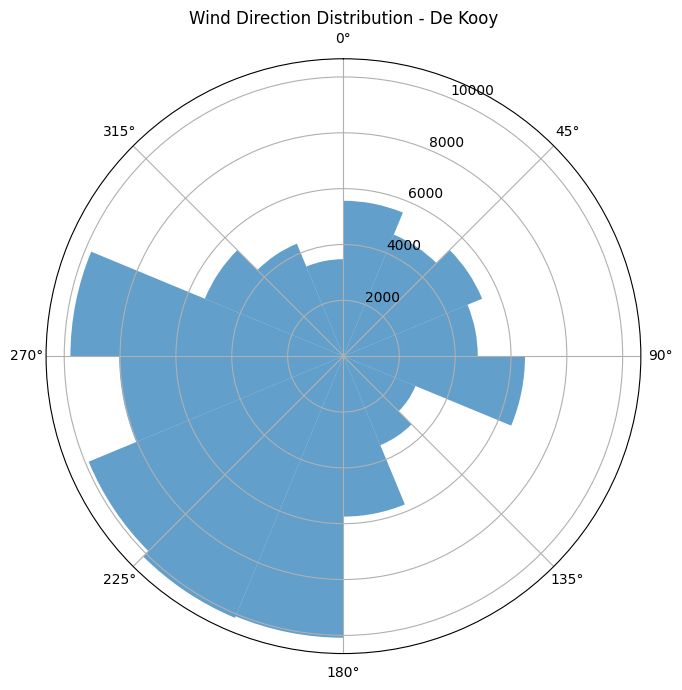

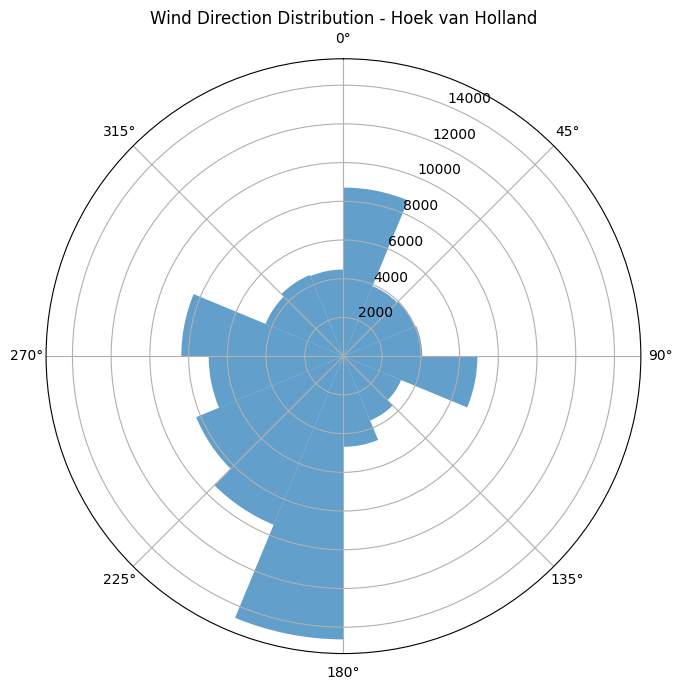

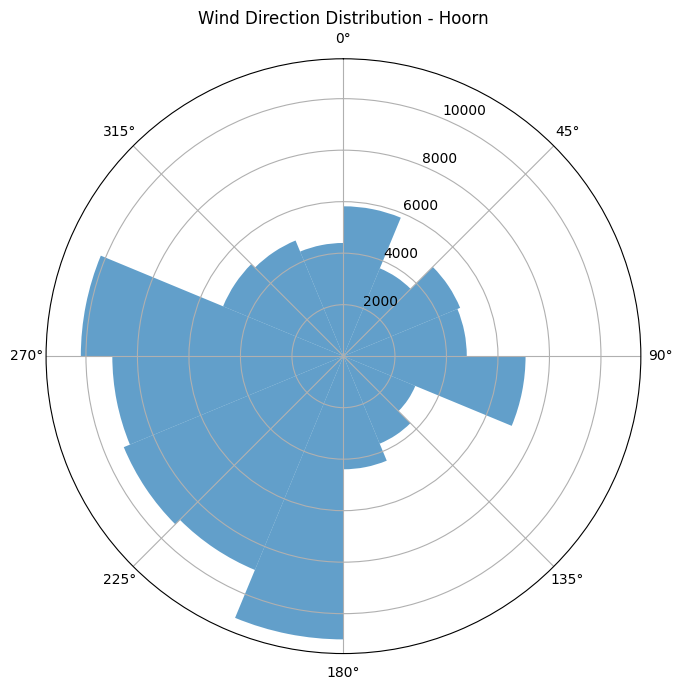

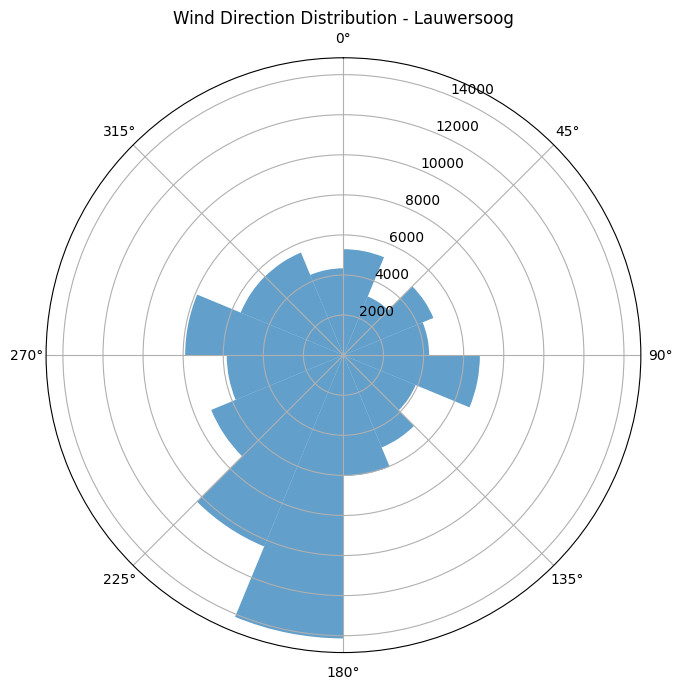

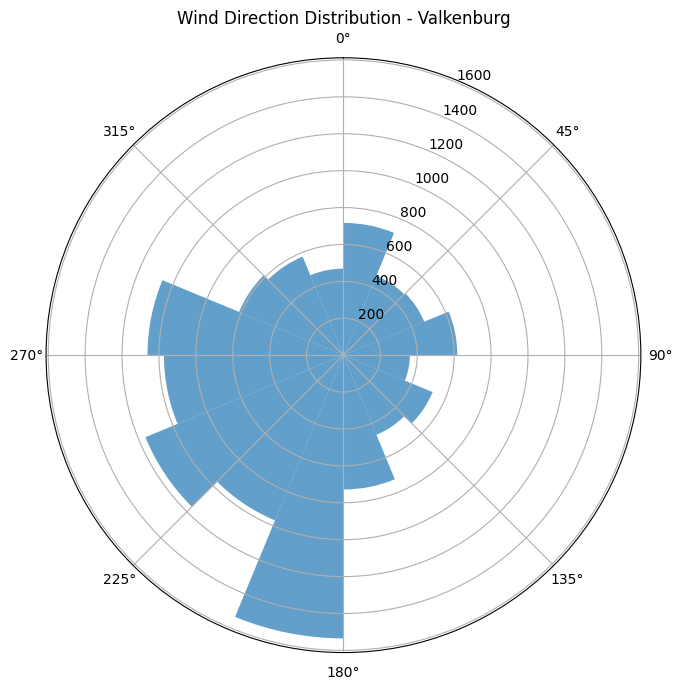

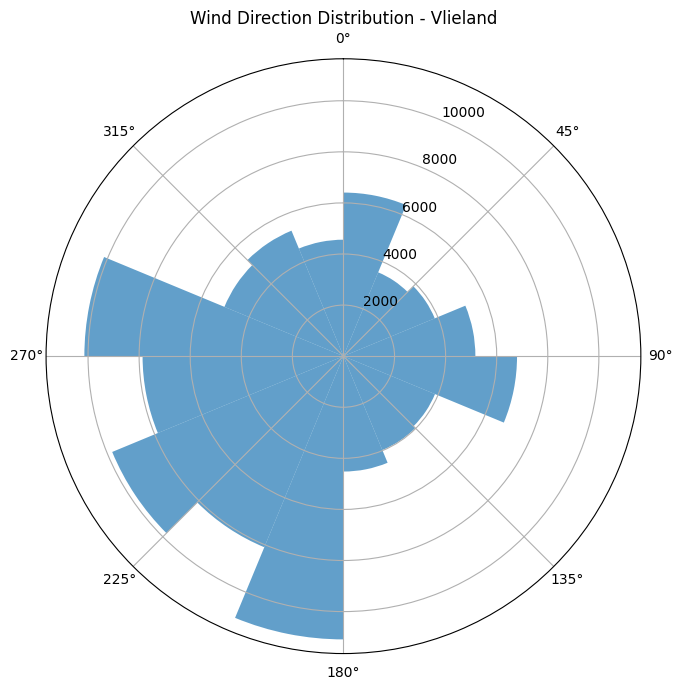

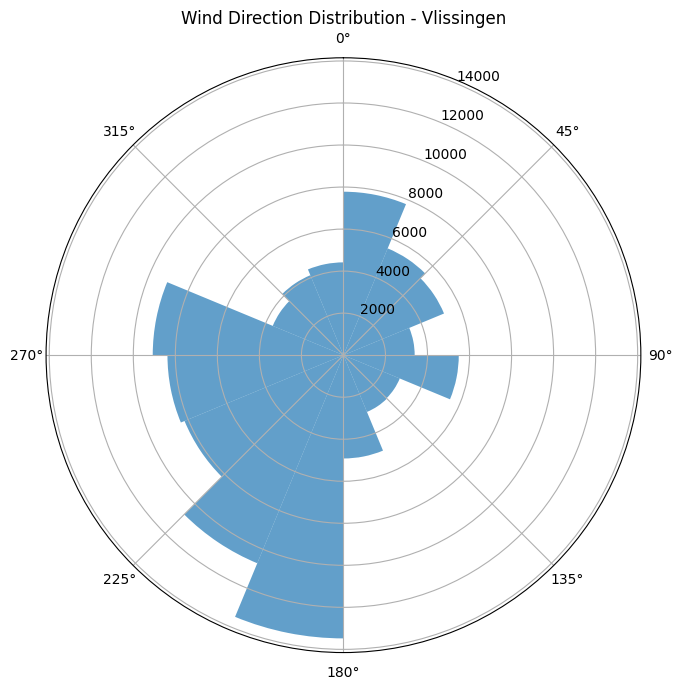

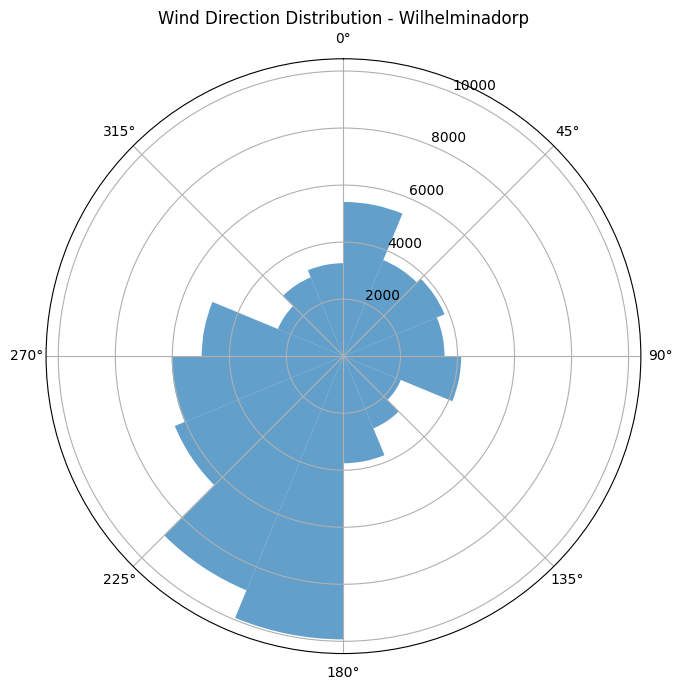

Visualisations completed successfully.


In [21]:
# ==========================================
# PB2-02 VISUALISATIONS
# Wind speed line plot + wind direction polar plots
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = final_knmi.copy()

station_col = "Station"
wind_speed_col = "wind_speed_ms"
wind_direction_col = "wind_direction_interpolated_deg"

df["timestamp"] = pd.to_datetime(df["timestamp"])
df[wind_speed_col] = pd.to_numeric(df[wind_speed_col], errors="coerce")
df[wind_direction_col] = pd.to_numeric(df[wind_direction_col], errors="coerce")

# ==========================================
# Monthly average wind speed by station
# ==========================================

monthly_wind = (
    df
    .set_index("timestamp")
    .groupby(station_col)[wind_speed_col]
    .resample("ME")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for station in monthly_wind[station_col].unique():
    station_data = monthly_wind[monthly_wind[station_col] == station]

    plt.plot(
        station_data["timestamp"],
        station_data[wind_speed_col],
        linewidth=1.5,
        label=str(station)
    )

plt.title("Monthly Average Wind Speed by KNMI Station")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_average_wind_speed_by_station.png",
    dpi=300
)

plt.show()


# ==========================================
# Wind direction polar plot - all stations
# ==========================================

wind_dir = df[[wind_direction_col]].dropna()

wind_dir = wind_dir[
    (wind_dir[wind_direction_col] >= 0)
    &
    (wind_dir[wind_direction_col] <= 360)
]

angles = np.deg2rad(wind_dir[wind_direction_col])

bins = np.linspace(0, 2 * np.pi, 17)
counts, edges = np.histogram(angles, bins=bins)

width = edges[1] - edges[0]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(
    edges[:-1],
    counts,
    width=width,
    align="edge",
    alpha=0.7
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_title("Wind Direction Distribution - All Stations")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_direction_distribution_all_stations.png",
    dpi=300
)

plt.show()


# ==========================================
# Wind direction polar plots per station
# ==========================================

stations = sorted(df[station_col].dropna().unique())

for station in stations:
    station_data = df[df[station_col] == station][[wind_direction_col]].dropna()

    station_data = station_data[
        (station_data[wind_direction_col] >= 0)
        &
        (station_data[wind_direction_col] <= 360)
    ]

    if station_data.empty:
        continue

    angles = np.deg2rad(station_data[wind_direction_col])

    bins = np.linspace(0, 2 * np.pi, 17)
    counts, edges = np.histogram(angles, bins=bins)

    width = edges[1] - edges[0]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    ax.bar(
        edges[:-1],
        counts,
        width=width,
        align="edge",
        alpha=0.7
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(f"Wind Direction Distribution - {station}")

    safe_name = str(station).replace(" ", "_").replace("/", "_")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"wind_direction_distribution_{safe_name}.png",
        dpi=300
    )

    plt.show()

print("Visualisations completed successfully.")

## 18. Short report text for the backlog

You can paste/adapt this in your sprint documentation.

In [40]:
report_text = f"""
For PB2-01, the KNMI hourly weather files were loaded from the raw KNMI dataset folder and combined into one dataset. Files belonging to the same weather station but different time periods were merged using the station number and timestamp. The dataset was then trimmed so that only observations from 2015 onward were kept. KNMI units were standardized: wind speed and gusts were converted from 0.1 m/s to m/s, temperature and dew point from 0.1°C to °C, pressure from 0.1 hPa to hPa, rainfall from 0.1 mm to mm, and sunshine/precipitation duration from 0.1 hours to hours. KNMI special values such as trace precipitation and trace sunshine were converted to zero, while variable wind direction was treated as missing.

Missing values were handled according to variable type. Continuous weather variables such as wind speed, temperature, dew point, pressure, humidity, radiation and visibility were interpolated over time within each station. Wind direction was converted into sine and cosine components before interpolation because wind direction is circular. Cloud cover was forward/backward filled and rounded because it is a discrete octant value. Precipitation values were filled with zero after KNMI trace precipitation values had already been cleaned.

For PB2-02, a correlation matrix was created using wind speed, gust speed, temperature, dew point, air pressure, humidity, cloud cover, global radiation, precipitation and wind direction components. Additional visualizations were produced, including wind speed against temperature, wind speed against air pressure, wind speed grouped by cloud cover, and monthly average wind speed by station. These outputs can be used to identify which weather variables have the strongest relationship with wind speed and to support the forecasting feature selection process.
"""
# Check what dataframe exists
